In [ ]:
!pip install ucimlrepo
import ucimlrepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [ ]:
# Cargar dataset
student_performance = fetch_ucirepo(id=320)
X_raw = student_performance.data.features
y_raw = student_performance.data.targets

# Agregar G1 y G2 como features
X_raw_con_g = X_raw.copy()
X_raw_con_g['G1'] = y_raw['G1']
X_raw_con_g['G2'] = y_raw['G2']

In [ ]:
# One-hot encoding
X_encoded = pd.get_dummies(X_raw_con_g).astype(float)

# Variable objetivo: G3 en 3 clases
_, bins = pd.qcut(y_raw['G3'], q=3, retbins=True, duplicates='drop')
bins[0], bins[-1] = -np.inf, np.inf
y_cls = pd.cut(y_raw['G3'], bins=bins, labels=[0, 1, 2]).astype(int).values

In [ ]:
# Selección de features por correlación con G3
X_corr = X_encoded.copy()
X_corr['G3'] = y_cls
correlations = X_corr.corr()['G3'].abs().drop('G3')

UMBRAL = 0.1
selected_features = correlations[correlations > UMBRAL].index.tolist()
print(f"Features seleccionadas ({len(selected_features)}): {selected_features}")

X = X_encoded[selected_features].values

Features seleccionadas (31): ['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'school_GP', 'school_MS', 'sex_F', 'sex_M', 'address_R', 'address_U', 'Mjob_at_home', 'Mjob_health', 'Mjob_teacher', 'Fjob_teacher', 'reason_course', 'reason_reputation', 'schoolsup_no', 'schoolsup_yes', 'activities_no', 'activities_yes', 'higher_no', 'higher_yes', 'internet_no', 'internet_yes']


In [ ]:
# Normalización
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot de etiquetas
y_ohe = pd.get_dummies(y_cls).values

In [ ]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_ohe, test_size=0.3, random_state=0, stratify=y_cls
)

# Class weights
y_train_cls = np.argmax(y_train, axis=1)
cw = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_train_cls)
class_weight_dict = {0: cw[0], 1: cw[1], 2: cw[2]}

In [ ]:
# Modelo
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, input_dim=X.shape[1], activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation='softmax')
])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=100,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2452 - loss: 1.3851 - val_accuracy: 0.2308 - val_loss: 1.2929
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2534 - loss: 1.2461 - val_accuracy: 0.3187 - val_loss: 1.1484
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3085 - loss: 1.1514 - val_accuracy: 0.4725 - val_loss: 1.0492
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4050 - loss: 1.0739 - val_accuracy: 0.6154 - val_loss: 0.9773
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4766 - loss: 1.0034 - val_accuracy: 0.6374 - val_loss: 0.9226
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5041 - loss: 0.9776 - val_accuracy: 0.7033 - val_loss: 0.8738
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5537 - loss: 0.9510 - val_accuracy: 0.7582 - val_loss: 0.8403
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5840 - loss: 0.9339 - val_accuracy: 0.7692 - val_loss: 0.

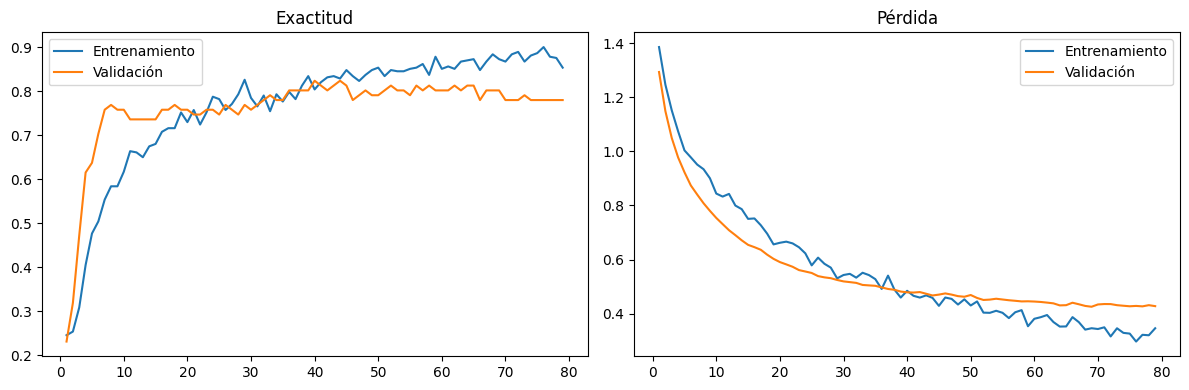

In [ ]:
# Curvas de entrenamiento
epochs_range = range(1, len(history.history['accuracy']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs_range, history.history['accuracy'], label='Entrenamiento')
ax1.plot(epochs_range, history.history['val_accuracy'], label='Validación')
ax1.set_title('Exactitud'); ax1.legend()
ax2.plot(epochs_range, history.history['loss'], label='Entrenamiento')
ax2.plot(epochs_range, history.history['val_loss'], label='Validación')
ax2.set_title('Pérdida'); ax2.legend()
plt.tight_layout()

In [ ]:
# Evaluación
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest loss: {loss:.4f} Test accuracy: {accuracy:.4f}')

y_pred    = model.predict(X_test)
actual    = np.argmax(y_test, axis=1)
predicted = np.argmax(y_pred, axis=1)


Test loss: 0.4331 | Test accuracy: 0.8256
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step



── Reporte de Clasificación ──
              precision    recall  f1-score   support

        Bajo       0.90      0.93      0.92        91
       Medio       0.63      0.63      0.63        46
        Alto       0.85      0.81      0.83        58

    accuracy                           0.83       195
   macro avg       0.80      0.79      0.79       195
weighted avg       0.82      0.83      0.82       195



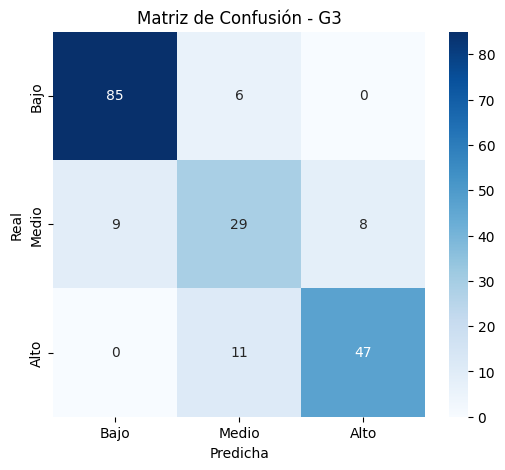

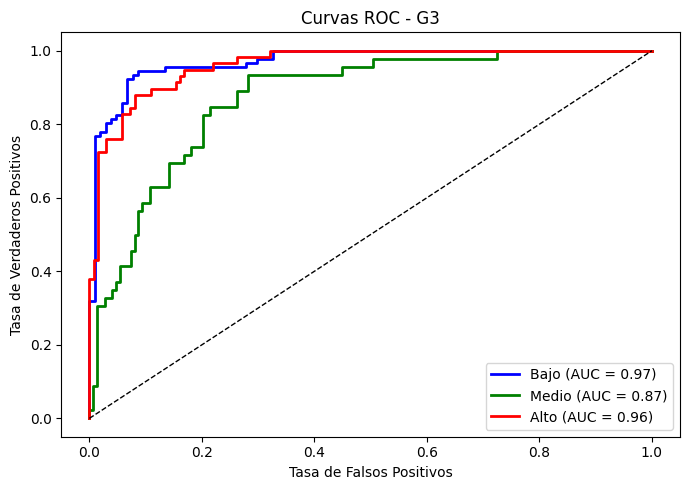

In [ ]:
# Matriz de confusión
cm = confusion_matrix(actual, predicted)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bajo', 'Medio', 'Alto'],
            yticklabels=['Bajo', 'Medio', 'Alto'])
plt.title('Matriz de Confusión G3')
plt.ylabel('Real'); plt.xlabel('Predicha')

# Métricas
print("\nReporte de Clasificación")
print(classification_report(actual, predicted,
                             target_names=['Bajo', 'Medio', 'Alto'],
                             zero_division=0))

# Curvas ROC
y_true_bin = label_binarize(actual, classes=[0, 1, 2])
fpr, tpr, roc_auc_cls = {}, {}, {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc_cls[i] = roc_auc_score(y_true_bin[:, i], y_pred[:, i])

plt.figure(figsize=(7, 5))
for i, color in zip(range(3), ['blue', 'green', 'red']):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"{'Bajo' if i==0 else 'Medio' if i==1 else 'Alto'} (AUC = {roc_auc_cls[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC G3')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()